In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
df = pd.concat([X, pd.Series(y, name='target')], axis=1)
print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature names:', iris.feature_names)
print('Target names:', iris.target_names.tolist())
df.head()

Features shape: (150, 4)
Target shape: (150,)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


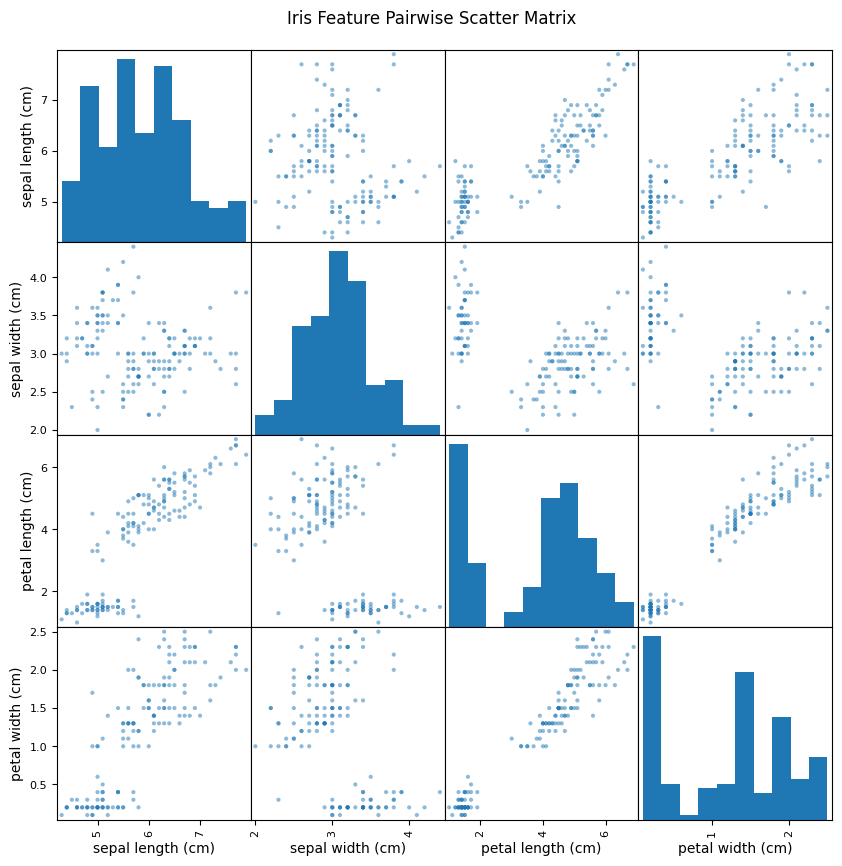

In [2]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

pd.options.display.max_columns = None

axes = scatter_matrix(X, figsize=(10, 10), diagonal='hist')
plt.suptitle('Iris Feature Pairwise Scatter Matrix', y=0.92)
plt.show()

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Train
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

# Predict & evaluate
y_pred = rf_classifier.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f'RandomForest Test Accuracy: {acc:.4f}\n')
print('Classification report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)

RandomForest Test Accuracy: 0.9000

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

Confusion matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


In [5]:
import os, joblib, pickle, json

os.makedirs('models', exist_ok=True)

# Save joblib
joblib.dump(rf_classifier, 'models/iris_model.joblib')

# Save pickle
with open('models/iris_model.pickle', 'wb') as f:
    pickle.dump(rf_classifier, f)

# Save metadata
model_info = {
    'model_type': 'RandomForestClassifier',
    'accuracy': float(acc),
    'feature_names': list(iris.feature_names),
    'target_names': list(iris.target_names)
}
with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

# Save feature ranges
feature_ranges = {
    'sepal_length': {'min': float(X['sepal length (cm)'].min()), 'max': float(X['sepal length (cm)'].max()), 'default': float(X['sepal length (cm)'].mean())},
    'sepal_width': {'min': float(X['sepal width (cm)'].min()), 'max': float(X['sepal width (cm)'].max()), 'default': float(X['sepal width (cm)'].mean())},
    'petal_length': {'min': float(X['petal length (cm)'].min()), 'max': float(X['petal length (cm)'].max()), 'default': float(X['petal length (cm)'].mean())},
    'petal_width': {'min': float(X['petal width (cm)'].min()), 'max': float(X['petal width (cm)'].max()), 'default': float(X['petal width (cm)'].mean())}
}
with open('models/feature_ranges.json', 'w') as f:
    json.dump(feature_ranges, f, indent=2)

print('All files saved successfully!')

All files saved successfully!


In [6]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import pickle
import json

st.set_page_config(
    page_title="Iris Flower Classifier",
    page_icon="🌸",
    layout="wide"
)

st.markdown("<h1 style='text-align: center; color: #6a0dad;'>🌸 Iris Flower Classification</h1>", unsafe_allow_html=True)
st.write("This app predicts the species of an Iris flower based on its measurements!")

@st.cache_resource
def load_model():
    return joblib.load('models/iris_model.joblib')

@st.cache_resource
def load_info():
    with open('models/model_info.json', 'r') as f:
        return json.load(f)

@st.cache_resource
def load_ranges():
    with open('models/feature_ranges.json', 'r') as f:
        return json.load(f)

model = load_model()
model_info = load_info()
feature_ranges = load_ranges()

st.header("📝 Input Features")

sepal_length = st.slider("Sepal Length (cm)", float(feature_ranges['sepal_length']['min']), float(feature_ranges['sepal_length']['max']), float(feature_ranges['sepal_length']['default']), 0.1)
sepal_width = st.slider("Sepal Width (cm)", float(feature_ranges['sepal_width']['min']), float(feature_ranges['sepal_width']['max']), float(feature_ranges['sepal_width']['default']), 0.1)
petal_length = st.slider("Petal Length (cm)", float(feature_ranges['petal_length']['min']), float(feature_ranges['petal_length']['max']), float(feature_ranges['petal_length']['default']), 0.1)
petal_width = st.slider("Petal Width (cm)", float(feature_ranges['petal_width']['min']), float(feature_ranges['petal_width']['max']), float(feature_ranges['petal_width']['default']), 0.1)

if st.button("🎯 Predict Species", type="primary"):
    input_features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
    prediction = model.predict(input_features)
    prediction_proba = model.predict_proba(input_features)[0]
    predicted_class = model_info['target_names'][prediction[0]]
    
    st.success(f"### Predicted Species: **{predicted_class}** 🌸")
    
    st.subheader("Confidence Scores:")
    for i, prob in enumerate(prediction_proba):
        st.progress(float(prob), text=f"{model_info['target_names'][i]}: {prob*100:.1f}%")

Writing app.py
